In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define the autoencoder model with 1D Convolutional layers
input_dim = X_scaled.shape[1]
latent_dim = 64

input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

autoencoder = Model(input_layer, decoder_layer5)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the data
autoencoder.fit(X_scaled, X_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])

Epoch 1/100
986/986 [==============================] - 75s 66ms/step - loss: 0.0055 - val_loss: 1.3611e-04
Epoch 2/100
986/986 [==============================] - 70s 71ms/step - loss: 8.2786e-05 - val_loss: 5.6659e-05
Epoch 3/100
986/986 [==============================] - 62s 63ms/step - loss: 5.3182e-05 - val_loss: 4.5390e-05
Epoch 4/100
986/986 [==============================] - 63s 64ms/step - loss: 4.3572e-05 - val_loss: 3.7745e-05
Epoch 5/100
986/986 [==============================] - 63s 64ms/step - loss: 3.7821e-05 - val_loss: 3.3076e-05
Epoch 6/100
986/986 [==============================] - 63s 64ms/step - loss: 3.4121e-05 - val_loss: 2.9618e-05
Epoch 7/100
986/986 [==============================] - 57s 58ms/step - loss: 3.0150e-05 - val_loss: 2.6586e-05
Epoch 8/100
986/986 [==============================] - 65s 66ms/step - loss: 2.8323e-05 - val_loss: 2.4102e-05
Epoch 9/100
986/986 [==============================] - 57s 58ms/step - loss: 2.5962e-05 - val_loss: 2.7534e-05
Epoch

1095/1095 [==============================] - 21s 18ms/step
Model saved at: trained_1D_autoencoder_model.h5
Threshold saved at: trained_1D_threshold.npy


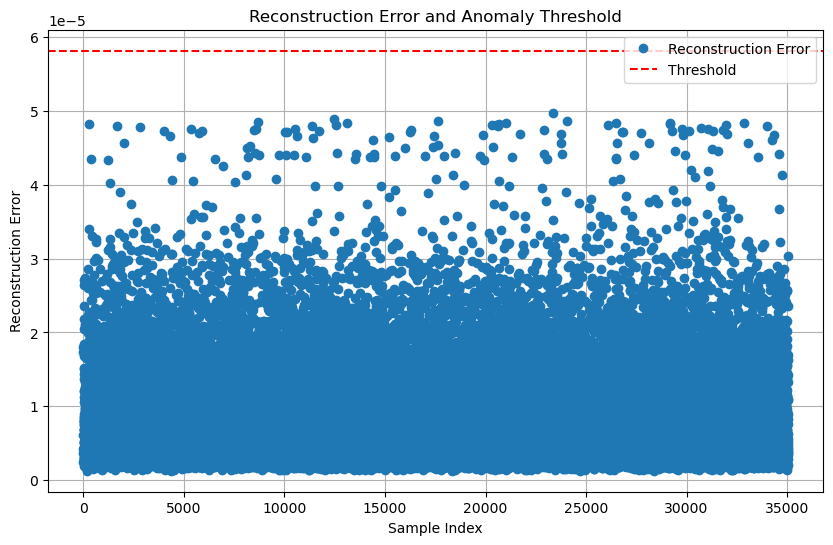

In [2]:
# Calculate reconstruction error
train_predictions = autoencoder.predict(X_scaled)
# reconstruction_error = np.mean(np.square(X_scaled - train_predictions), axis=1)
#################################################################################
# Calculate reconstruction error
reshaped_train_predictions = train_predictions.reshape(X_scaled.shape)  # Reshape to match original input shape
reconstruction_error = np.mean(np.square(X_scaled - reshaped_train_predictions), axis=1)
################################################################################

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (16 * mad)

# Print and save the trained autoencoder model
model_path = "trained_1D_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_1D_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold')
plt.legend()
plt.grid()
plt.show()


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the 1D Convolutional Autoencoder model
# input_dim = X_train_scaled.shape[1]
# latent_dim = 64

# input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
# encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
# encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
# encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
# encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

# decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
# decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
# decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
# decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
# decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

# autoencoder = Model(input_layer, decoder_layer5)
# autoencoder.compile(optimizer='adam', loss='mse')

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
# anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\AppData\Local\Temp\ipykernel_28952\2022420320.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_28952\2022420320.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


9/9 [==============================] - 1s 36ms/step
Threshold saved at: 5.8133915165968344e-05
Anomalous Data Indices:
[  0   2   6  10  27  28  33  39  43  44  45  47  50  55  74  77  91  97
  98 107 112 116 123 128 132 144 150 152 158 190 191 194 195 199 212 214
 237 249 250 277 282 286 287]


Accuracy: 0.6493055555555556
Precision: 0.9767441860465116
Recall: 0.29577464788732394
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.704225352112676
F1 Score: 0.4540540540540541
ROC AUC: 0.7766737410765966


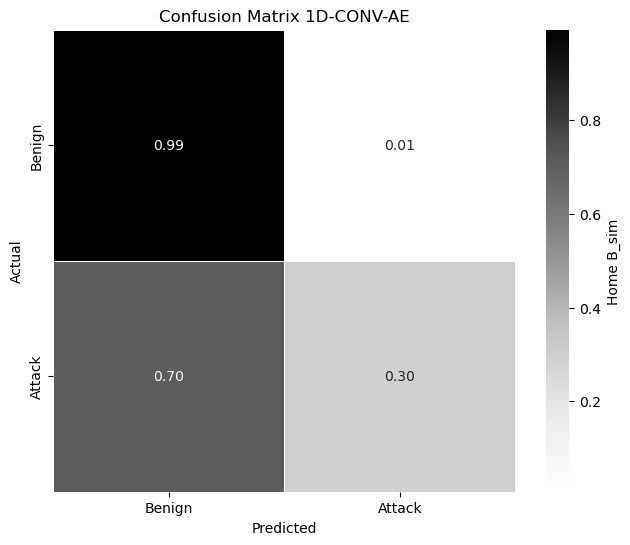

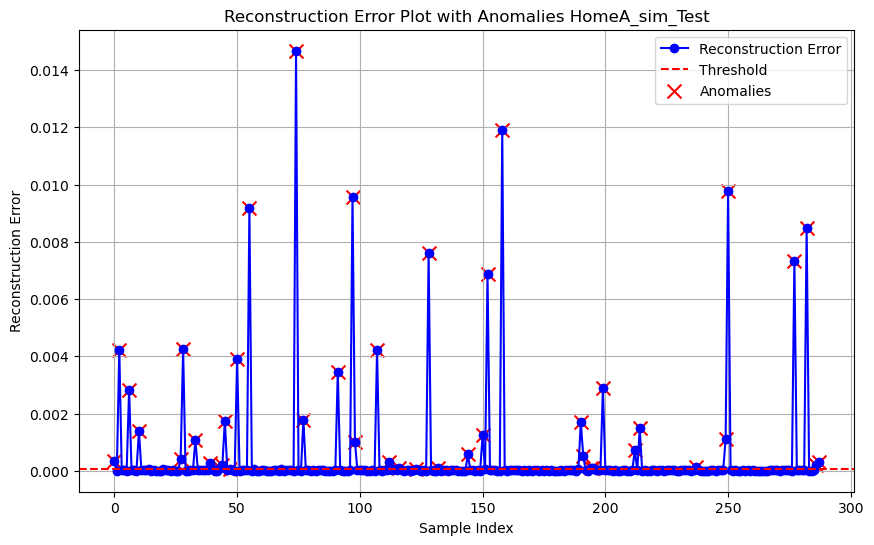

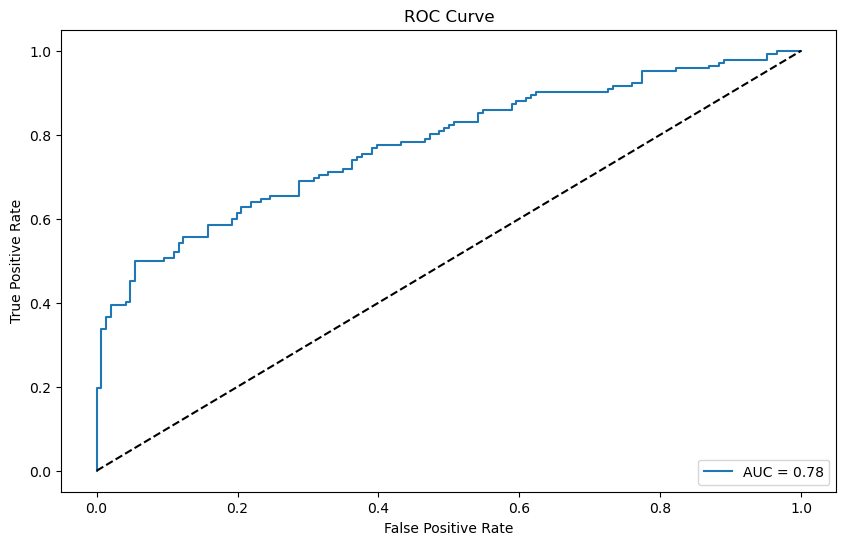

In [4]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home B_sim'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix 1D-CONV-AE')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\1D-CONV-B_anomalies_sim_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the 1D Convolutional Autoencoder model
# input_dim = X_train_scaled.shape[1]
# latent_dim = 64

# input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
# encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
# encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
# encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
# encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

# decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
# decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
# decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
# decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
# decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

# autoencoder = Model(input_layer, decoder_layer5)
# autoencoder.compile(optimizer='adam', loss='mse')

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
# anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\AppData\Local\Temp\ipykernel_28952\2755573688.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_28952\2755573688.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


548/548 [==============================] - 19s 34ms/step
Threshold saved at: 5.8133915165968344e-05
Anomalous Data Indices:
[  101   126   133   134   154   168   170   224   252   263   274   279
   288   325   346   356   420   427   441   490   517   592   605   624
   642   644   686   723   744   780   783   825   878   882   944   966
   975   985   988  1036  1044  1057  1071  1109  1167  1177  1182  1188
  1201  1202  1211  1212  1260  1274  1287  1317  1323  1324  1329  1344
  1354  1377  1384  1386  1391  1401  1446  1455  1461  1499  1503  1523
  1549  1598  1599  1617  1656  1657  1663  1710  1711  1724  1763  1770
  1830  1849  1868  1888  1920  1925  1942  1964  2004  2013  2016  2055
  2108  2117  2168  2170  2181  2200  2201  2214  2246  2259  2333  2340
  2349  2367  2394  2416  2422  2483  2547  2617  2624  2630  2650  2651
  2672  2689  2734  2749  2754  2769  2801  2846  2874  2879  2903  2962
  2981  3021  3043  3044  3053  3093  3122  3137  3174  3188  3193  3204


Accuracy: 0.5365867579908675
Precision: 0.8932515337423312
Recall: 0.08310502283105023
TNR: 0.9900684931506849
FPR: 0.00993150684931507
FNR: 0.9168949771689497
F1 Score: 0.1520626631853786
ROC AUC: 0.7183011457225663


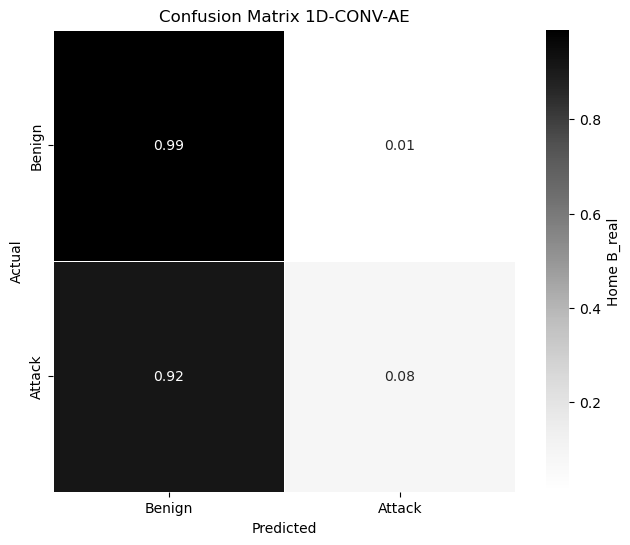

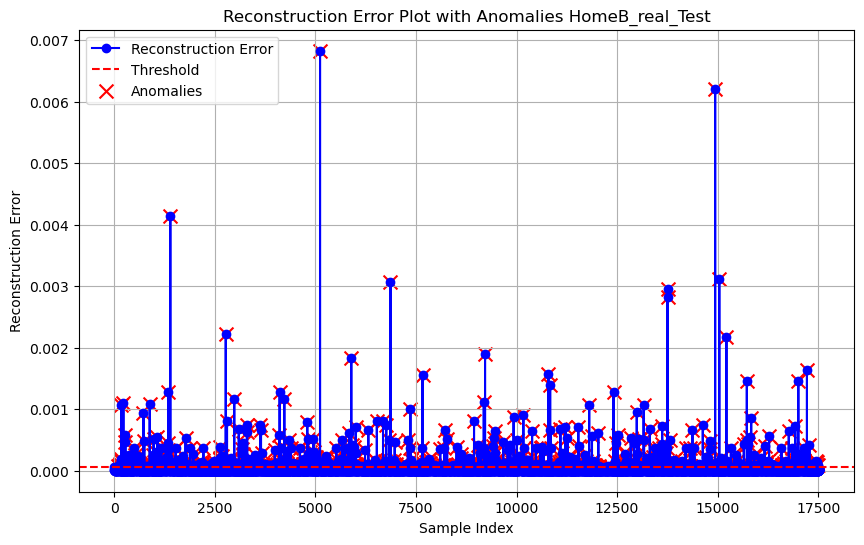

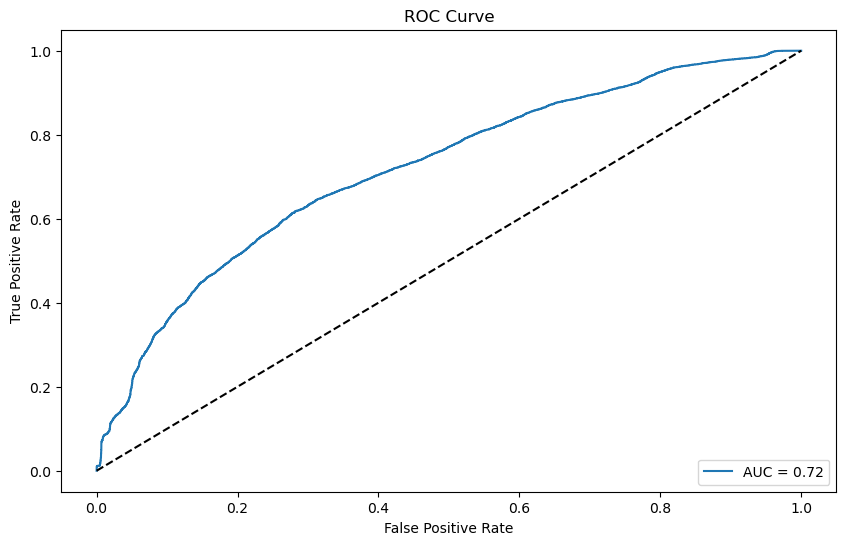

In [6]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home B_real'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix 1D-CONV-AE')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\1D-CONV-B_anomalies_real_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define the 1D Convolutional Autoencoder model with downsampling
input_dim = X_scaled.shape[1]
encoding_dim = 64

input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

autoencoder = Model(input_layer, decoder_layer5)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=64,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])


Epoch 1/50
493/493 [==============================] - 42s 76ms/step - loss: 0.0118 - val_loss: 2.7969e-04
Epoch 2/50
493/493 [==============================] - 38s 77ms/step - loss: 1.8715e-04 - val_loss: 1.2351e-04
Epoch 3/50
493/493 [==============================] - 38s 77ms/step - loss: 9.2770e-05 - val_loss: 7.2635e-05
Epoch 4/50
493/493 [==============================] - 38s 76ms/step - loss: 6.3635e-05 - val_loss: 5.5055e-05
Epoch 5/50
493/493 [==============================] - 38s 78ms/step - loss: 5.3488e-05 - val_loss: 4.7639e-05
Epoch 6/50
493/493 [==============================] - 38s 77ms/step - loss: 4.9266e-05 - val_loss: 4.2318e-05
Epoch 7/50
493/493 [==============================] - 38s 77ms/step - loss: 4.1888e-05 - val_loss: 3.8474e-05
Epoch 8/50
493/493 [==============================] - 38s 77ms/step - loss: 4.0297e-05 - val_loss: 3.9529e-05
Epoch 9/50
493/493 [==============================] - 39s 79ms/step - loss: 3.5948e-05 - val_loss: 3.3262e-05
Epoch 10/50
49

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1380, 1)]         0         
                                                                 
 conv1d_5 (Conv1D)           (None, 1380, 32)          128       
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 690, 32)          0         
 1D)                                                             
                                                                 
 conv1d_6 (Conv1D)           (None, 690, 64)           6208      
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 345, 64)          0         
 1D)                                                             
                                                                 
 conv1d_7 (Conv1D)           (None, 345, 64)           1235

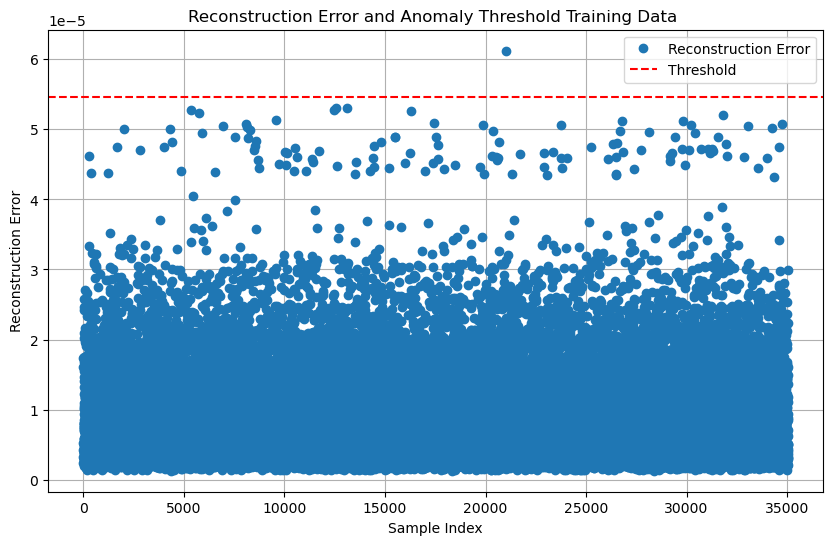

In [19]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for training data
# train_predictions = autoencoder.predict(X_scaled)
# reconstruction_error = np.mean(np.square(X_scaled - train_predictions), axis=1)

reshaped_train_predictions = train_predictions.reshape(X_scaled.shape)  # Reshape to match original input shape
reconstruction_error = np.mean(np.square(X_scaled - reshaped_train_predictions), axis=1)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (16 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_1D-autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_1D-threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Training Data ')
plt.legend()
plt.grid()
plt.show()

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

C:\Users\olufe\AppData\Local\Temp\ipykernel_35272\3266478880.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_35272\3266478880.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


9/9 [==============================] - 1s 31ms/step
Threshold saved at: 0.00027998133676901713
Anomalous Data Indices:
[  0   2   6  10  27  28  33  39  45  50  55  74  77  91  97  98 107 112
 128 144 150 152 158 190 191 199 212 214 249 250 277 282 287]


Accuracy: 0.6145833333333334
Precision: 0.9696969696969697
Recall: 0.22535211267605634
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.7746478873239436
F1 Score: 0.36571428571428577
ROC AUC: 0.7691973760370442
Confusion Matrix:
 [[145   1]
 [110  32]]


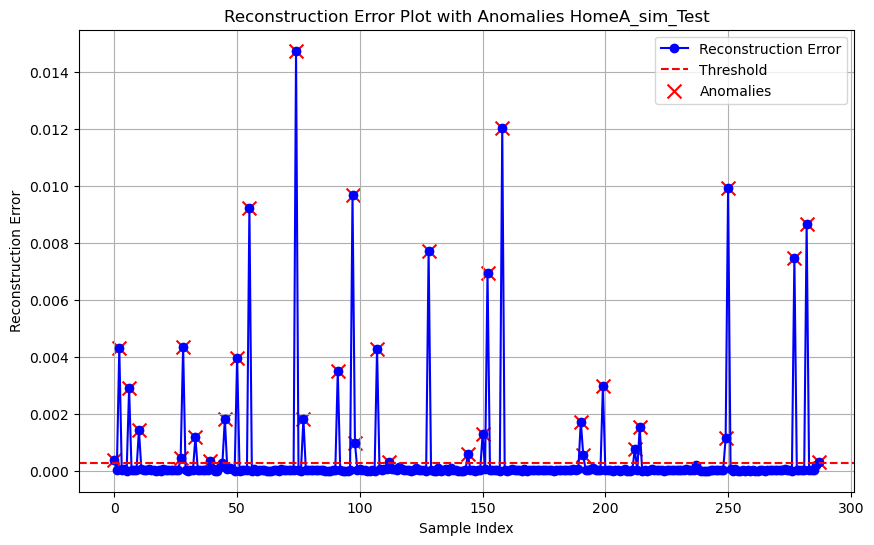

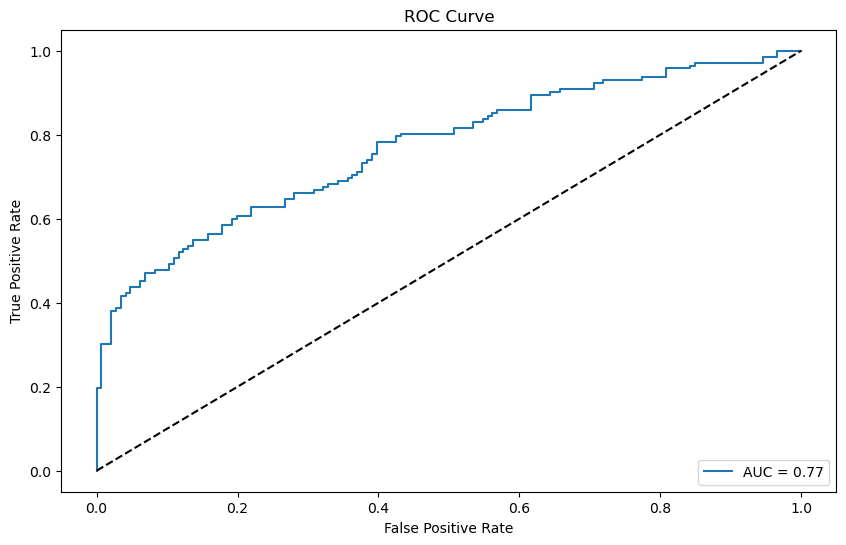

In [2]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

C:\Users\olufe\AppData\Local\Temp\ipykernel_35272\956972787.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_35272\956972787.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


548/548 [==============================] - 13s 22ms/step
Threshold saved at: 0.00027998133676901713
Anomalous Data Indices:
[  168   224   252   274   490   723   744   878   975  1044  1071  1167
  1323  1324  1344  1391  1523  1770  1888  1964  2214  2624  2769  2801
  2981  3093  3174  3188  3204  3294  3302  3628  3646  3666  3990  4100
  4109  4150  4226  4280  4343  4386  4612  4797  4818  4824  4852  4949
  4973  5114  5238  5519  5668  5723  5810  5813  5838  5891  5904  5949
  6000  6004  6233  6315  6526  6680  6761  6833  6865  6970  7297  7361
  7363  7652  7662  8103  8201  8219  8275  8509  8627  8943  9049  9082
  9103  9185  9193  9217  9250  9424  9436  9460  9463  9670  9780  9825
  9847  9927 10007 10072 10170 10187 10387 10483 10598 10606 10630 10670
 10793 10836 10843 10863 11091 11137 11217 11267 11537 11555 11712 11807
 11876 12034 12411 12463 12520 12840 12917 12989 12991 13042 13160 13171
 13313 13326 13397 13435 13542 13555 13622 13625 13653 13715 13750 13754


Accuracy: 0.5054223744292238
Precision: 0.768361581920904
Recall: 0.015525114155251141
TNR: 0.9953196347031964
FPR: 0.0046803652968036525
FNR: 0.9844748858447488
F1 Score: 0.03043526910596397
ROC AUC: 0.7375541194929214
Confusion Matrix:
 [[8719   41]
 [8624  136]]


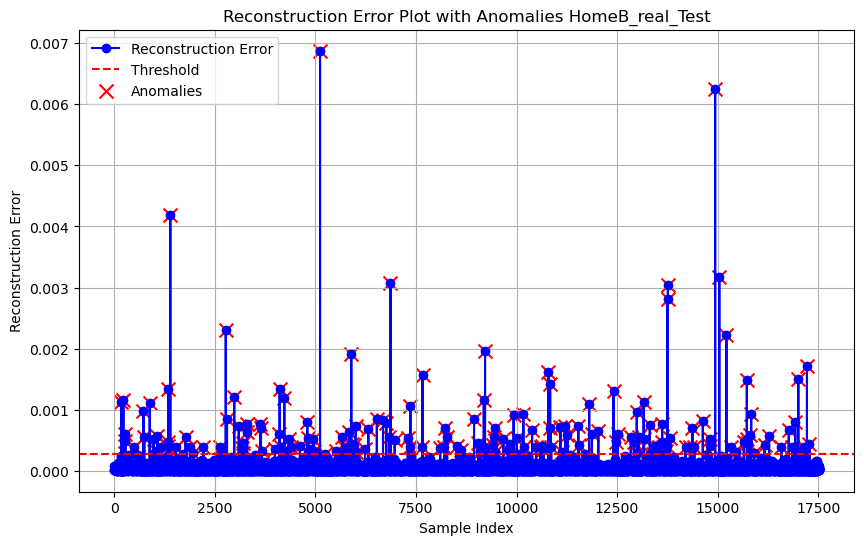

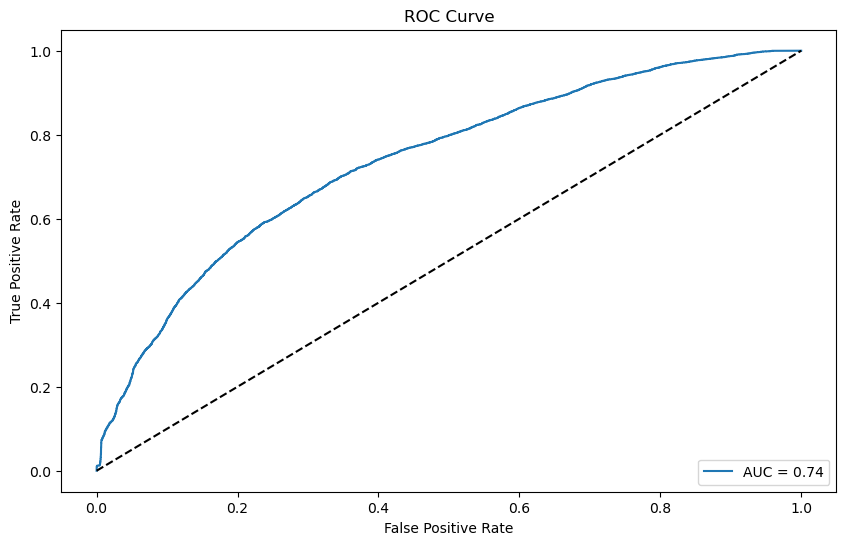

In [4]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
